# Steane Circ Level Noise (single round)

Data generation and analysis
+ different decoder: ML, MWPM
+ different observables: Z,X
+ different distances
+ different noise levels

analysis: 
+ show asymptotic behavior (not important)
+ determine thresholds


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, smart_read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER


## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.9,-1,dtype=float)]
distances = [3,5,7,9,11,13,15] # 3 is newly included not yet in data
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [3]:
# Folder names (for writing data to file):
w_folder_name_ML_Z = "circ_md_1r_steane_Z_ML"
w_folder_name_ML_X = "circ_md_1r_steane_X_ML"
w_folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"
w_folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"

In [4]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [5]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,w_folder_name_ML_Z,backup=True)

In [6]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_Z)

In [7]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,w_folder_name_ML_X,backup=True)

In [8]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_X)

In [9]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,w_folder_name_MWPM_Z,backup=True)

In [10]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_Z)

In [11]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,w_folder_name_MWPM_X,backup=True)

In [12]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_X)

# Analysis

In [13]:
# Folder paths (reading in data)
r_folder_name_ML_Z = "circ_md_1r_steane_Z_ML"
r_folder_name_ML_X = "circ_md_1r_steane_X_ML"
r_folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"
r_folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"


In [ ]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [15]:
# General fit parameters: 
g_pth_ml_Z = [0.028]
g_pth_ml_X = [0.035]
g_pth_mwpm_Z = [0.027]
g_pth_mwpm_X = [0.035]

g_nu = [1.5]

p_window = [10**(0.15)]
min_distance = [5]

In [16]:
folder_name = r_folder_name_ML_Z
g_pth = g_pth_ml_Z

result = analysis_pipeline(
    folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/fu494742/MasterArbeit/code/data/circ_md_1r_steane_Z_ML/data.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

(array([0.0247781]),)
(array([0.04943881]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.2339280285747611
             x: [ 3.642e-02  6.233e-01]
           nit: 51
          nfev: 95
 final_simplex: (array([[ 3.642e-02,  6.233e-01],
                       [ 3.642e-02,  6.233e-01],
                       [ 3.642e-02,  6.233e-01]]), array([ 1.234e+00,  1.234e+00,  1.234e+00]))
[0.03641664]
[0.00471076]


<Figure size 640x480 with 0 Axes>

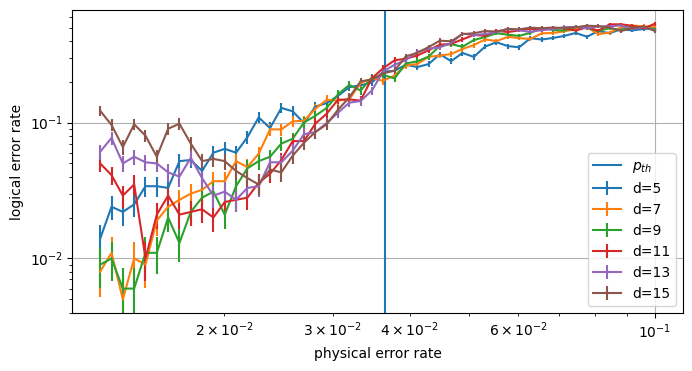

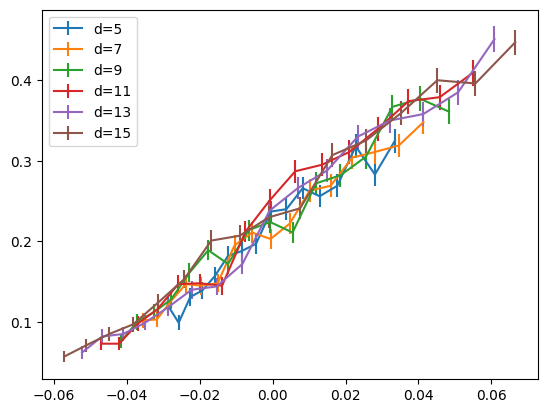

<Figure size 640x480 with 0 Axes>

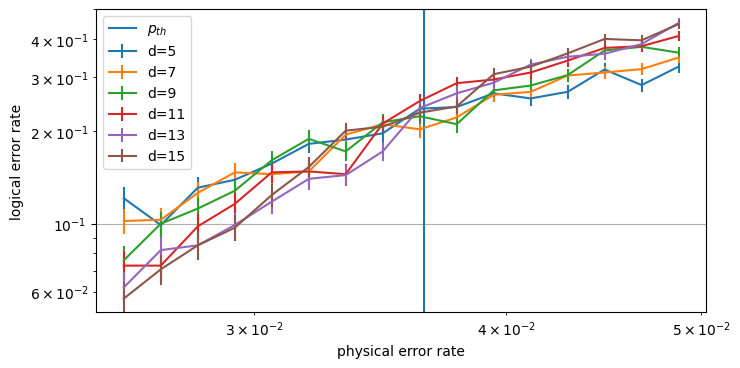

[0.03641664]
[1.60428602]


In [ ]:
folder_name = r_folder_name_ML_X 
g_pth = g_pth_ml_X

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result

(array([0.01911454]),)
(array([0.03813851]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7089691118168792
             x: [ 2.736e-02  6.896e-01]
           nit: 55
          nfev: 103
 final_simplex: (array([[ 2.736e-02,  6.896e-01],
                       [ 2.736e-02,  6.896e-01],
                       [ 2.736e-02,  6.897e-01]]), array([ 7.090e-01,  7.090e-01,  7.090e-01]))
[0.02735755]
[0.00067018]


<Figure size 640x480 with 0 Axes>

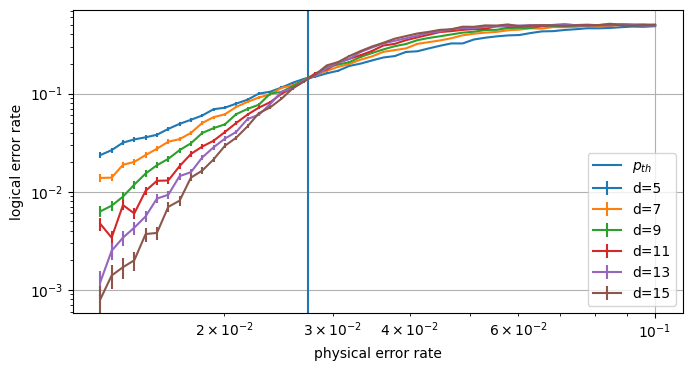

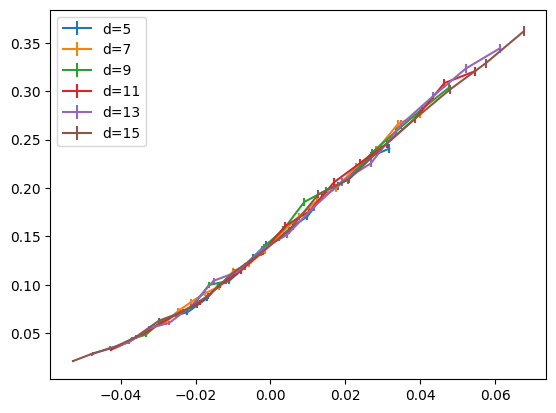

<Figure size 640x480 with 0 Axes>

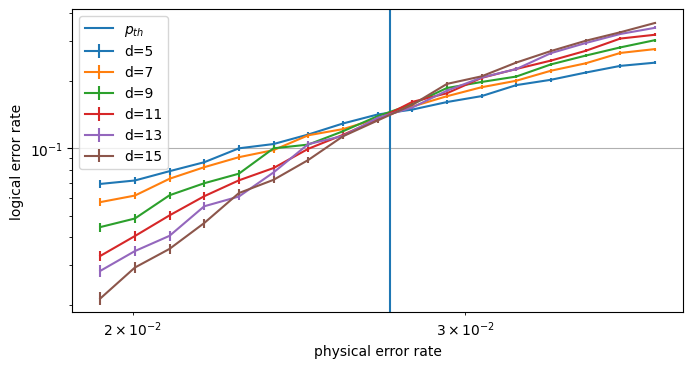

[0.02735755]
[1.45001211]


In [ ]:
folder_name = r_folder_name_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

(array([0.0247781]),)
(array([0.04943881]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1957763109506143
             x: [ 3.234e-02  7.085e-01]
           nit: 34
          nfev: 67
 final_simplex: (array([[ 3.234e-02,  7.085e-01],
                       [ 3.234e-02,  7.085e-01],
                       [ 3.234e-02,  7.085e-01]]), array([ 1.196e+00,  1.196e+00,  1.196e+00]))
[0.03234357]
[0.0012276]


<Figure size 640x480 with 0 Axes>

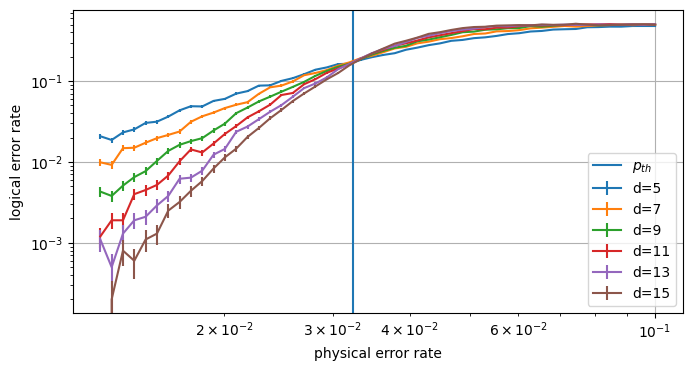

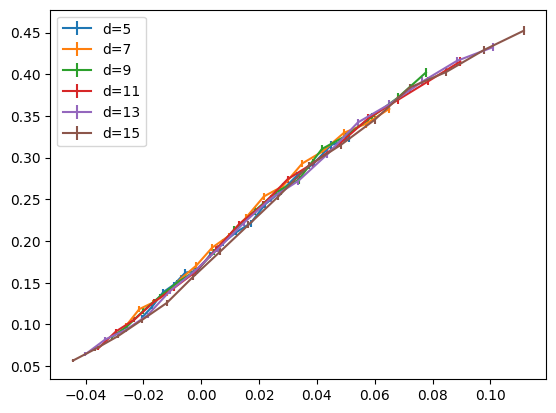

<Figure size 640x480 with 0 Axes>

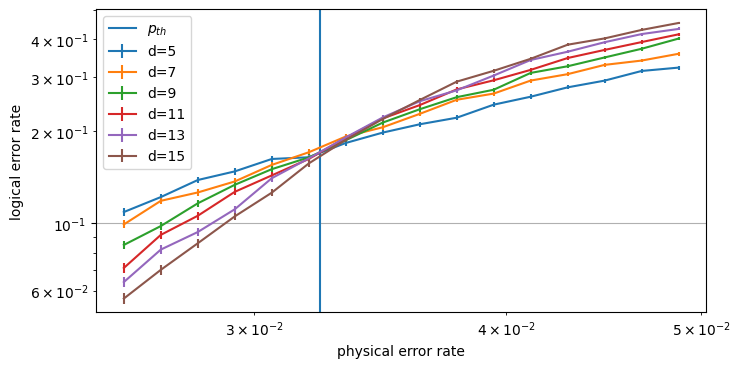

[0.03234357]
[1.41147233]


In [ ]:
folder_name = r_folder_name_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Thresholds Results (1 round circ noise)

In [ ]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 



For ML Z: threshold = 2.795 +- 0.288
For ML X: threshold = 3.642 +- 0.471
For MWPM Z: threshold = 2.736 +- 0.067
For MWPM X: threshold = 3.234 +- 0.123


X error Threshold seems to be higher. 
Does this fit expectation? 

Z errors corrected first => more not tracked errors introduce by circ noise => residual error is higher => fits expectations.

## Varying parameters

In [ ]:
# as collections
folder_names = [r_folder_name_ML_Z, r_folder_name_ML_X, r_folder_name_MWPM_Z, r_folder_name_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml_Z, g_pth_ml_X, g_pth_mwpm_Z, g_pth_mwpm_X] 

g_nus = [g_nu] * 4

In [ ]:
# Varying distance
min_distances = [5,7,9]
n_distances = 3

window_distance = 2 * n_distances  

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 
for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        result = analysis_pipeline(
            folder_name = folder_names[i],
            guess_pth = g_pths[i],
            guess_nu = g_nus[i],
            min_distance = [min_distances[j]], 
            max_distance = [min_distances[j] + window_distance],
            p_window= p_window,
            plots=False,
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]

(array([0.01982248]),)
(array([0.03955105]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9077346205178723
             x: [ 2.788e-02  6.604e-01]
           nit: 55
          nfev: 107
 final_simplex: (array([[ 2.788e-02,  6.604e-01],
                       [ 2.788e-02,  6.604e-01],
                       [ 2.788e-02,  6.604e-01]]), array([ 9.077e-01,  9.077e-01,  9.077e-01]))
[0.02788277]
[0.00326606]
(array([0.0247781]),)
(array([0.04943881]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.4174078017523088
             x: [ 3.500e-02  6.252e-01]
           nit: 64
          nfev: 121
 final_simplex: (array([[ 3.500e-02,  6.252e-01],
                       [ 3.500e-02,  6.252e-01],
                       [ 3.500e-02,  6.252e-01]]), array([ 1.417e+00,  1.417e+00,  1.417e+00]))
[0.03500052]
[0.00517661]
(array([0.01911454]),)
(array([0.03813851]),)

    

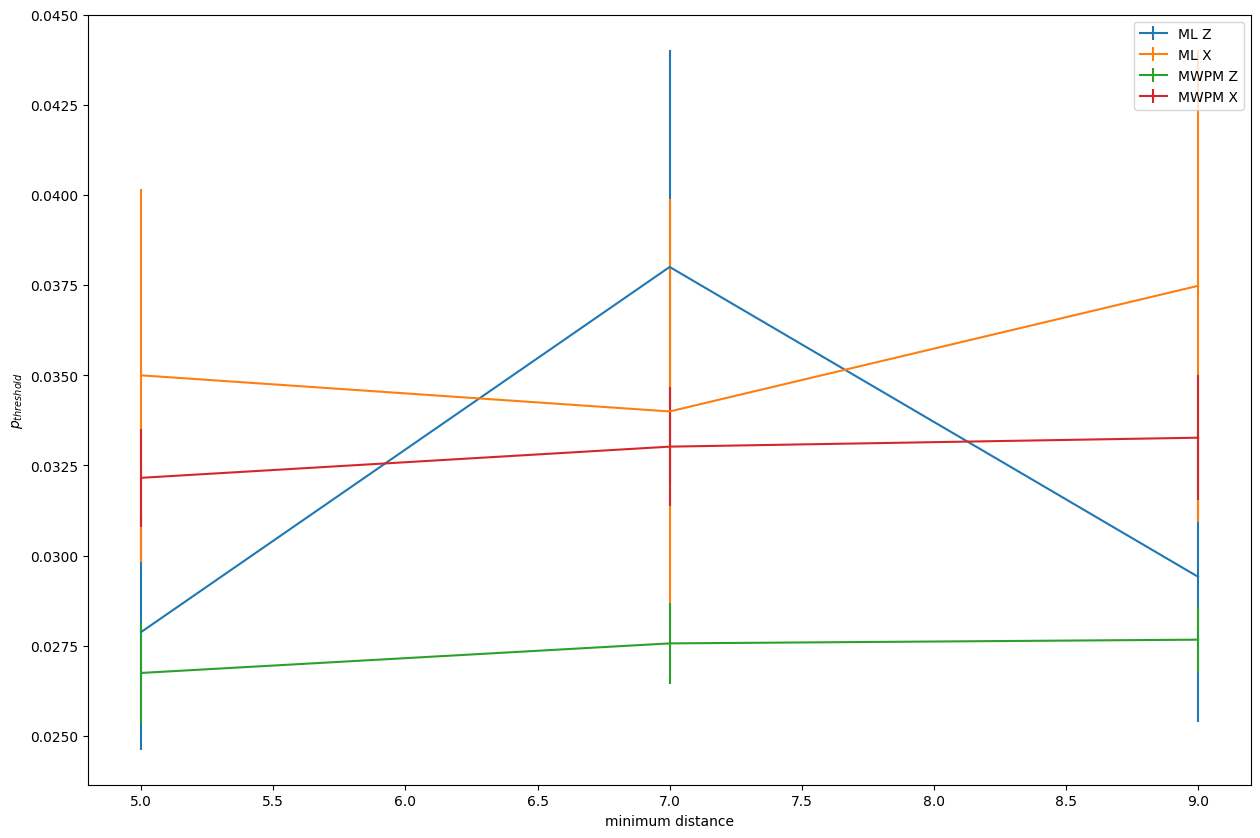

In [ ]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
plt.ylabel("$p_{threshold}$")
# plt.yscale("log")
plt.legend()
plt.show()